In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## **Class definition**

In [13]:
class CellularAutomaton:
    """
    Cellular Automaton simulator for forest fire propagation using 2D grid operations.
    
    The evolution of the state grid is determined by local physical environmental 
    factors (wind and topography) unique to each cell, bypassing standard convolution 
    to allow for spatially varying propagation rules.
    """

    def __init__(self, grid_height: int, grid_width: int, neighborhood: list[tuple], 
                 wind_grid: np.ndarray, height_grid: np.ndarray) -> None:
        """
        Initialize the automaton with environmental parameters.

        Args:
            grid_height (int): Number of rows in the grid.
            grid_width (int): Number of columns in the grid.
            neighborhood (list[tuple]): List of relative offsets (di, dj) defining neighbors.
            wind_grid (np.array): Wind influence factors for each cell (2D array).
            height_grid (np.array): Terrain influence factors for each cell (2D array).
        """
        self.state_grid = np.zeros((grid_height, grid_width))
        self.neighborhood = neighborhood
        self.wind_grid = wind_grid
        self.height_grid = height_grid

    def get_state(self) -> np.ndarray:
        """
        Retrieve the current state of the grid.

        Returns:
            np.array: The 2D array representing the automaton's current state.
        """
        return self.state_grid

    def evolve(self) -> None:
        """
        Advance the automaton by one time step.
        
        Calculates propagation by summing the states of neighbors for each cell,
        weighted by the specific local wind and height factors stored in 2D grids.
        """
        if not self.neighborhood:
            return None

        new_influences = np.zeros_like(self.state_grid)
        rows, cols = self.state_grid.shape

        for di, dj in self.neighborhood:
            shifted_states = np.zeros_like(self.state_grid)
            
            r_start, r_end = max(0, di), min(rows, rows + di)
            c_start, c_end = max(0, dj), min(cols, cols + dj)
            
            r_orig_start, r_orig_end = max(0, -di), min(rows, rows - di)
            c_orig_start, c_orig_end = max(0, -dj), min(cols, cols - dj)
            
            shifted_states[r_start:r_end, c_start:c_end] = \
                self.state_grid[r_orig_start:r_orig_end, c_orig_start:c_orig_end]
            
            new_influences += shifted_states

        propagation_map = new_influences * self.wind_grid * self.height_grid
        self.state_grid = np.clip(self.state_grid + propagation_map, 0, 1)
        return None

    def initialize_ignition(self, start_points: list[tuple], init_states: list[float]) -> None:
        """
        Initialize starting points for the fire (ignition).

        Args:
            start_points (list[tuple]): List of (i, j) coordinates where the fire starts.
            init_states (list[float]): Initial fire intensity for each point (typically 1.0).
        """
        for idx, point in enumerate(start_points):
            i, j = point
            if 0 <= i < self.state_grid.shape[0] and 0 <= j < self.state_grid.shape[1]:
                self.state_grid[i, j] = init_states[idx]
        return None


## **Examples :**

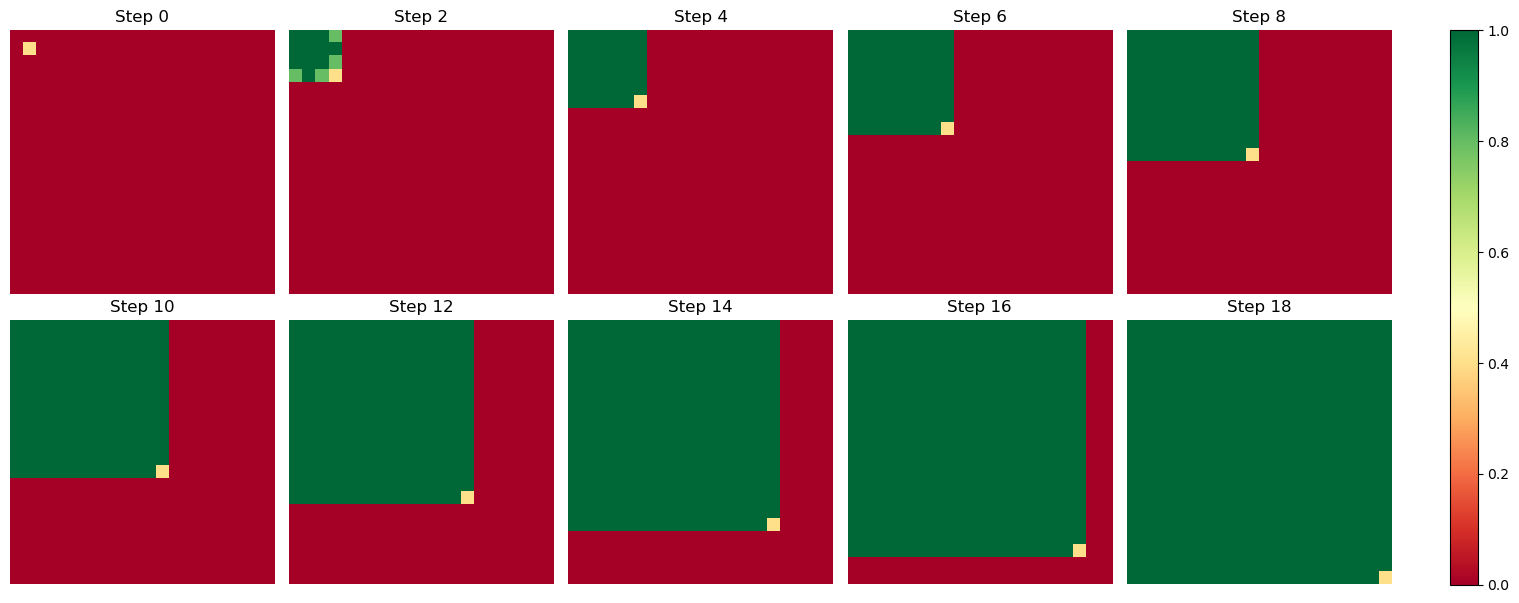

In [40]:
neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1), (1, 1), (-1, -1), (1, -1), (-1, 1)]

weights = np.ones((20, 20))
heights = np.ones((20, 20))

CA = CellularAutomaton(20, 20, neighbors, weights, heights)

CA.initialize_ignition([(1, 1)], [0.4])


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
plot_idx = 0

for step in range(20):
    if step % 2 == 0 and plot_idx < 10:
        current_state = CA.get_state()
        im = axes[plot_idx].imshow(current_state, vmin=0, vmax=1, cmap='RdYlGn')
        axes[plot_idx].set_title(f"Step {step}")
        axes[plot_idx].axis('off')
        plot_idx += 1

    CA.evolve()

plt.tight_layout()
plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
plt.show()